# Supplementary Material 4
[Article Title Here]

Submitted to: [Journal Name Here]

Jorge Lizarazo¹, Gustavo A. Londoño², Judit Ungvari Martin³ ⁴, Justin Baldwin⁵ & Scott K. Robinson⁶

¹ Center for Animals on the Move, Department of Biology, Western University, London, ON, Canada
² Department of Biological Sciences, Bioprocesses and Biotechnology, Icesi University, Cali, Colombia
³ Future Earth Global Secretariat, New York, NY, USA
⁴ Institute for a Sustainable Earth, George Mason University, Fairfax, VA, USA
⁵ Department of Ecology and Evolutionary Biology, University of California, Santa Cruz, USA
⁶ Florida Museum of Natural History, University of Florida, Gainesville, Florida, USA

Corresponding authors:

Jorge Lizarazo  Jorge.lizarazo.b@gmail.com &
Gustavo A. Londoño  galondono@icesi.edu.co

This analysis quantifies how nest mass influences egg cooling rates during incubation recesses. Cooling curves were derived from controlled nest experiments in which heated eggs were allowed to cool under ambient conditions while temperature was recorded at high temporal resolution. The analysis estimates the cooling constant of each nest type, predicts temperature trajectories during recess intervals, and evaluates how nest mass influences the time required for eggs to reach the physiological zero temperature (26 °C).

In [1]:
import pandas as pd
import numpy as np
import glob
import os
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm


## S4.1 Experimental Temperature Dataset

The experimental dataset consists of continuous temperature recordings obtained from artificial nests of different masses (8 g, 22 g, and 35 g). Each file contains a timestamp, egg temperature, and ambient temperature recorded during controlled cooling trials.

Files were imported, standardized, and labelled according to nest mass category to allow comparison of thermal properties among nest types.


In [2]:
path = r"D:\Mimus\excitu"
files = glob.glob(path + "/*.txt")

In [3]:
%%capture
dfs = []

for f in files:

    df = pd.read_csv(f, sep="\t")

    df.columns = ["datetime","egg_temp","ambient_temp"]
    df["datetime"] = pd.to_datetime(df["datetime"])

    name = os.path.basename(f)

    if "_8g" in name:
        nest = "8g"
    elif "_22g" in name:
        nest = "22g"
    elif "_35g" in name:
        nest = "35g"

    df["file"] = name
    df["nest_type"] = nest

    dfs.append(df)

data = pd.concat(dfs)

In [4]:
data

,datetime,egg_temp,ambient_temp,file,nest_type
0,2006-10-20 16:57:38,44.40,21.71,ALS38_35g.txt,35g
1,2006-10-20 16:57:39,44.40,21.71,ALS38_35g.txt,35g
2,2006-10-20 16:57:40,44.40,21.71,ALS38_35g.txt,35g
3,2006-10-20 16:57:41,44.40,21.71,ALS38_35g.txt,35g
4,2006-10-20 16:57:42,44.40,21.71,ALS38_35g.txt,35g
...,...,...,...,...,...
6907,2006-09-23 18:07:18,22.86,22.48,SD_151_35g.txt,35g
6908,2006-09-23 18:07:19,22.86,22.86,SD_151_35g.txt,35g
6909,2006-09-23 18:07:20,22.86,22.48,SD_151_35g.txt,35g
6910,2006-09-23 18:07:21,22.86,22.48,SD_151_35g.txt,35g


## S4.2 Isolation of Cooling Phases

For each recording, the cooling phase was isolated by identifying the moment when egg temperature was closest to 40 °C and retaining all subsequent observations. This ensures that the analysed time series captures the full cooling trajectory following simulated incubation departure.

Cooling traces were limited to the first 2,600 seconds (~43 minutes) to standardize the analysis window across experiments. Files showing unrealistic temperatures (>55 °C) were excluded to avoid artefacts.

In [5]:
data = data.sort_values(["file","datetime"])

trimmed = []

for file, g in data.groupby("file"):

    g = g.sort_values("datetime")

    # find temperature closest to 40°C
    idx = (g["egg_temp"] - 40).abs().idxmin()

    # keep only cooling phase
    g = g.loc[idx:].copy()

    # reset time
    g["time_sec"] = np.arange(len(g))

    trimmed.append(g)

data = pd.concat(trimmed).reset_index(drop=True)

# limit to first 35 minutes (2100 seconds)
data = data[data["time_sec"] <= 2600]

# REMOVE BAD NESTS
bad_files = (
    data.groupby("file")["egg_temp"]
    .max()
    .loc[lambda x: x > 55]
    .index
)

print("Files removed:", bad_files)

data = data[~data["file"].isin(bad_files)].copy()

Files removed: Index(['SD10_22g.txt'], dtype='object', name='file')


After trimming each trace starting at the 40°C moment, keeping only the subsequent cooling (~2,600 seconds), and dropping files whose egg temperatures rose above 55°C, we retain the cleaned long-format dataset for curve fitting.

## S4.3 Exponential Cooling Model

Egg cooling was modeled using an exponential cooling function derived from Newton’s law of cooling:

T(t) = Tenv + (T0 − Tenv) e^(−kt)

where T(t) represents egg temperature at time t, Tenv is ambient temperature, T0 is the initial egg temperature, and k is the cooling constant describing the rate of heat loss.

Cooling constants were estimated for each experimental trace using non-linear least squares.

In [6]:
def cooling(t, k, Tenv, T0):
    return Tenv + (T0 - Tenv) * np.exp(-k * t)

## S4.4 Estimation of Cooling Constants

Cooling constants (k) were estimated independently for each experimental trace. These values describe the rate at which eggs lose heat when incubation is interrupted. The resulting dataset contains one cooling constant estimate per experimental replicate, allowing comparison among nest mass categories.

In [7]:
results = []

for file, g in data.groupby("file"):

    # safeguard: skip files that became too short after trimming
    if len(g) < 50:
        continue

    t = g["time_sec"].values
    T = g["egg_temp"].values

    Tenv = g["ambient_temp"].mean()
    T0 = T[0]

    try:

        popt,_ = curve_fit(
            lambda t,k: cooling(t,k,Tenv,T0),
            t,
            T,
            p0=[0.0003],
            bounds=(0,0.01)
        )

        k = popt[0]

    except:
        k = np.nan

    results.append({
        "file":file,
        "nest_type":g["nest_type"].iloc[0],
        "k":k
    })

k_df = pd.DataFrame(results)

## S4.5 Time Required to Reach Physiological Zero Temperature

To evaluate the biological implications of nest insulation, we calculated the time required for egg temperature to decline to 26 °C, the approximate physiological zero temperature below which embryonic development ceases.

For each cooling trace, the first time at which egg temperature reached 26 °C was recorded.

In [8]:
time26 = []

for file, g in data.groupby("file"):

    # find the first moment temperature drops to 26°C or below
    idx = g[g["egg_temp"] <= 26]

    if len(idx) == 0:
        continue

    t26 = idx["time_sec"].iloc[0]

    time26.append({
        "file": file,
        "nest_type": g["nest_type"].iloc[0],
        "time_to_26_sec": t26
    })

time26_df = pd.DataFrame(time26)

In [9]:
time26_df["time_to_26_min"] = time26_df["time_to_26_sec"] / 60

In [10]:
print(time26_df)

                file nest_type  time_to_26_sec  time_to_26_min
0      ALS38_35g.txt       35g            1143       19.050000
1       ALS38_8g.txt        8g            1220       20.333333
2    ALS47_A_22g.txt       22g             870       14.500000
3    ALS47_A_35g.txt       35g             936       15.600000
4     ALS47_A_8g.txt        8g             854       14.233333
..               ...       ...             ...             ...
152      SD3_22g.txt       22g            1097       18.283333
153      SD3_35g.txt       35g            1209       20.150000
154      SD7_35g.txt       35g            1098       18.300000
155   SD_151_22g.txt       22g            1333       22.216667
156   SD_151_35g.txt       35g            1448       24.133333

[157 rows x 4 columns]


In [11]:
t_pred = np.linspace(0,2600,400)

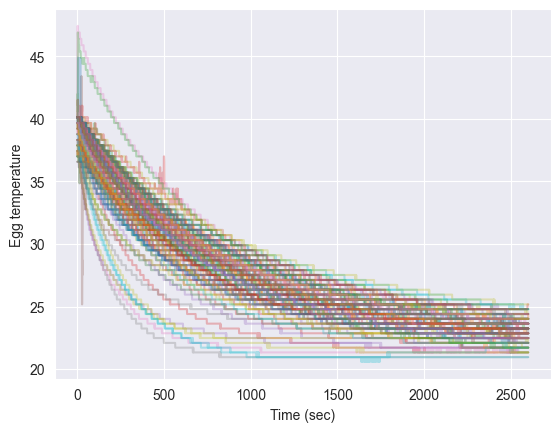

In [12]:
for file, g in data.groupby("file"):
    plt.plot(g["time_sec"], g["egg_temp"], alpha=0.3)

plt.xlabel("Time (sec)")
plt.ylabel("Egg temperature")
plt.show()

## S4.6 Predicted Cooling Trajectories

Average cooling constants were calculated for each nest mass category and used to generate predicted temperature trajectories.

Confidence bands were constructed using the standard error of the cooling constant estimates. These curves illustrate how quickly eggs cool under different nest insulation conditions.

In [13]:
summary_k = (
    k_df
    .groupby("nest_type")["k"]
    .agg(["mean","std","count"])
    .reset_index()
)

summary_k["se"] = summary_k["std"] / np.sqrt(summary_k["count"])

In [14]:
env_summary = (
    data.groupby("nest_type")
    .agg(
        Tenv=("ambient_temp","mean"),
        T0=("egg_temp","first")
    )
    .reset_index()
)

In [15]:
pred_list = []

for nest in summary_k["nest_type"]:

    k_mean = summary_k.loc[summary_k["nest_type"]==nest,"mean"].values[0]
    k_se   = summary_k.loc[summary_k["nest_type"]==nest,"se"].values[0]

    Tenv = env_summary.loc[env_summary["nest_type"]==nest,"Tenv"].values[0]
    T0   = env_summary.loc[env_summary["nest_type"]==nest,"T0"].values[0]

    t = t_pred

    temp_mean = cooling(t, k_mean, Tenv, T0)
    temp_low  = cooling(t, k_mean - k_se, Tenv, T0)
    temp_high = cooling(t, k_mean + k_se, Tenv, T0)

    pred_list.append(pd.DataFrame({
        "time":t,
        "temp":temp_mean,
        "low":temp_low,
        "high":temp_high,
        "nest":nest
    }))

pred_df = pd.concat(pred_list)

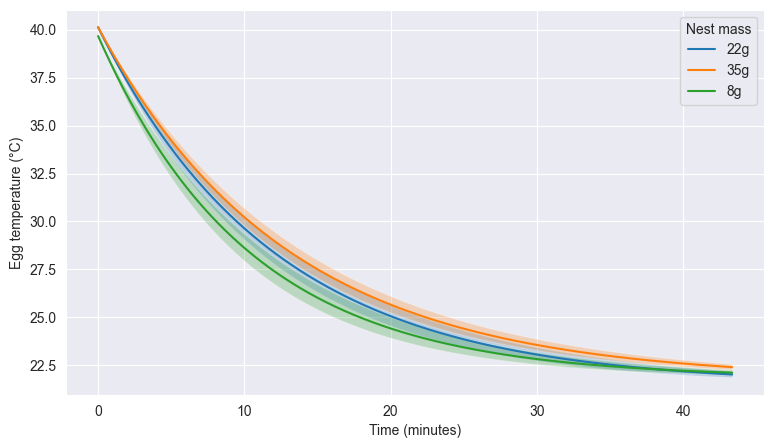

In [16]:
plt.figure(figsize=(9,5))

for nest in pred_df["nest"].unique():

    g = pred_df[pred_df["nest"]==nest]

    plt.plot(g["time"]/60, g["temp"], label=nest)

    plt.fill_between(
        g["time"]/60,
        g["low"],
        g["high"],
        alpha=0.25
    )

plt.xlabel("Time (minutes)")
plt.ylabel("Egg temperature (°C)")
plt.legend(title="Nest mass")
plt.show()

In [17]:
colors = {
    "8g":  "#a00000",
    "22g": "#98c127",
    "35g": "#003a7d"
}

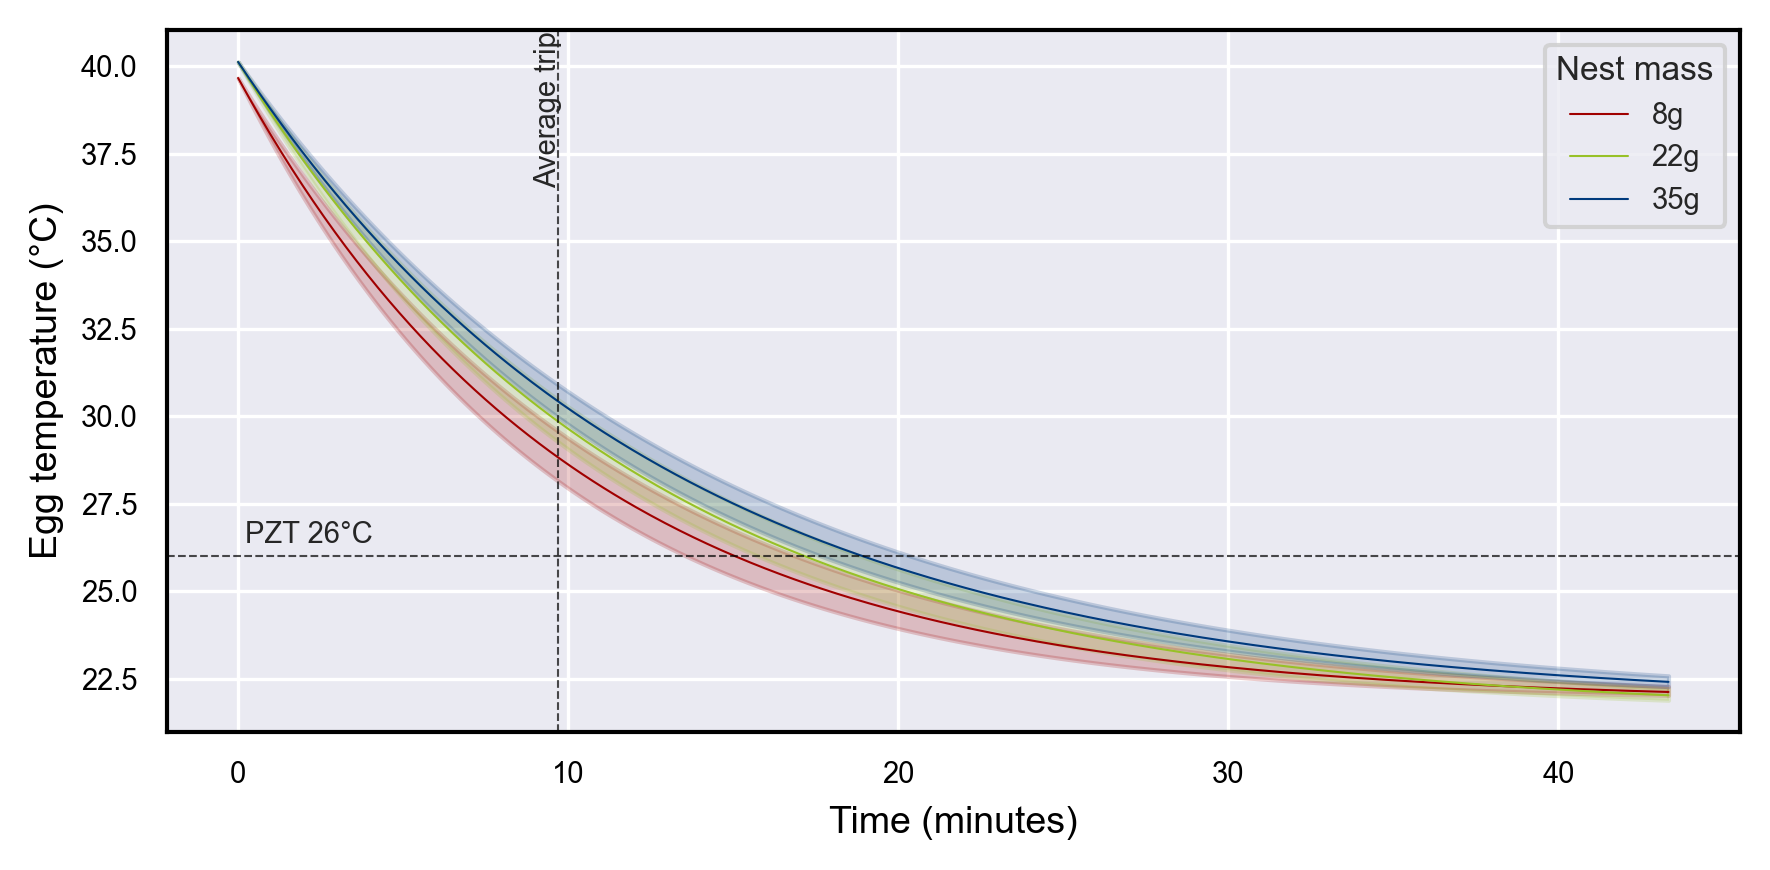

In [18]:
fig, ax = plt.subplots(figsize=(6,3), dpi=300)

colors = {
    "8g":  "#a00000",
    "22g": "#98c127",
    "35g": "#003a7d"
}

for nest in ["8g","22g","35g"]:

    g = pred_df[pred_df["nest"] == nest]

    ax.plot(
        g["time"]/60,
        g["temp"],
        color=colors[nest],
        linewidth=.5,
        label=nest
    )

    ax.fill_between(
        g["time"]/60,
        g["low"],
        g["high"],
        color=colors[nest],
        alpha=0.2
    )

ax.set_xlabel("Time (minutes)", fontsize=9)
ax.set_ylabel("Egg temperature (°C)", fontsize=9)

ax.tick_params(axis='x', labelsize=7)
ax.tick_params(axis='y', labelsize=7)

ax.legend(title="Nest mass", fontsize=7, title_fontsize=8)

ax.axhline(26, color='black', linestyle='--', alpha=0.7, linewidth=.5)
ax.axvline(9.7, color='black', linestyle='--', alpha=0.7, linewidth=.5)
# label horizontal line
ax.text(
    0.2, 26.2,
    "PZT 26°C",
    fontsize=7,
    ha="left",
    va="bottom"
)
# label vertical line
ax.text(
    9.8, 41,
    "Average trip",
    rotation=90,
    fontsize=7,
    ha="right",
    va="top"
)

# Force axis elements to black
for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1)

ax.tick_params(axis='both', colors='black')
ax.xaxis.label.set_color('black')
ax.yaxis.label.set_color('black')



plt.tight_layout()

plt.savefig(
    "Figures/Nest_Cooling_Curves.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)

plt.show()

In [19]:
#Nest_Cooling_Curves.png

In [20]:
import seaborn as sn

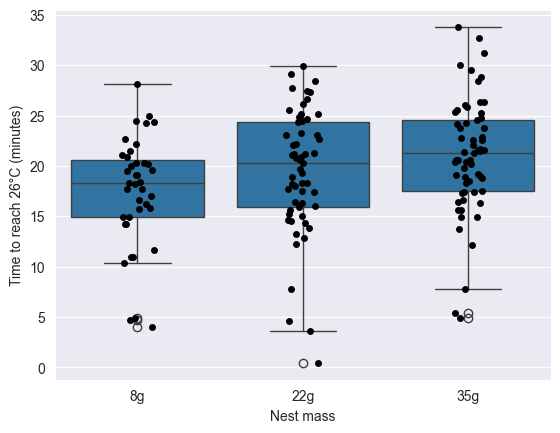

In [21]:
order = ["8g", "22g", "35g"]

sn.boxplot(data=time26_df, x="nest_type", y="time_to_26_min", order=order)
sn.stripplot(data=time26_df, x="nest_type", y="time_to_26_min", order=order, color="black")

plt.ylabel("Time to reach 26°C (minutes)")
plt.xlabel("Nest mass")
plt.show()

In [22]:
time26_df["nest_type"] = pd.Categorical(
    time26_df["nest_type"],
    categories=["8g","22g","35g"],
    ordered=True
)

The final figures group the fitted cooling constants by nest mass, plot the predicted trajectories with uncertainty bands, and then model `time_to_26_min` as a function of ordered `nest_type` while running Tukey comparisons and plotting the predicted differences.

## S4.7 Comparison Among Nest Masses

The influence of nest mass on cooling dynamics was evaluated by modelling the time required for eggs to reach 26 °C as a function of nest mass category.

Pairwise differences among nest types were evaluated using Tukey post-hoc comparisons.

In [23]:
model_time = smf.glm(
    "time_to_26_min ~ C(nest_type)",
    data=time26_df,
    family=sm.families.Gaussian()
).fit()

print(model_time.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:         time_to_26_min   No. Observations:                  157
Model:                            GLM   Df Residuals:                      154
Model Family:                Gaussian   Df Model:                            2
Link Function:               Identity   Scale:                          34.764
Method:                          IRLS   Log-Likelihood:                -499.82
Date:                Fri, 13 Mar 2026   Deviance:                       5353.7
Time:                        17:28:16   Pearson chi2:                 5.35e+03
No. Iterations:                     3   Pseudo R-squ. (CS):            0.05386
Covariance Type:            nonrobust                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              17.4474    

In [24]:
import statsmodels.stats.multicomp as mc

comp = mc.MultiComparison(time26_df["time_to_26_min"], time26_df["nest_type"])
print(comp.tukeyhsd())

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   22g    35g   1.5874 0.3124 -0.9832  4.1579  False
   22g     8g  -1.9619 0.2482 -4.8616  0.9378  False
   35g     8g  -3.5493 0.0106 -6.4101 -0.6884   True
----------------------------------------------------


In [25]:
pred_input = pd.DataFrame({
    "nest_type": ["8g", "22g", "35g"]
})

pred = model_time.get_prediction(pred_input)
pred_summary = pred.summary_frame()

In [26]:
pred_input["mean"] = pred_summary["mean"]
pred_input["se"] = pred_summary["mean_se"]

pred_input["low"] = pred_input["mean"] - pred_input["se"]
pred_input["high"] = pred_input["mean"] + pred_input["se"]

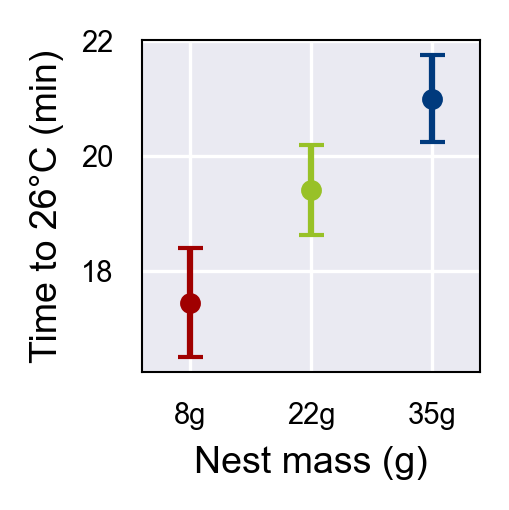

In [27]:
fig, ax = plt.subplots(figsize=(1.8,1.8), dpi=300)


x_pos = [0.95, 1.0, 1.05]

for i, row in pred_input.iterrows():

    nest = row["nest_type"]

    ax.errorbar(
        x=x_pos[i],
        y=row["mean"],
        yerr=row["se"],
        fmt="o",
        color=colors[nest],
        capsize=3,
        markersize=4
    )


# Force axis elements to black
for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(0.5)

ax.tick_params(axis='both', colors='black')
ax.xaxis.label.set_color('black')
ax.yaxis.label.set_color('black')

ax.set_xticks(x_pos)
ax.set_xticklabels(["8g","22g","35g"])

# CLAVE para quitar el espacio
ax.set_xlim(0.93, 1.07)

ax.set_xlabel("Nest mass (g)", fontsize=9)
ax.set_ylabel("Time to 26°C (min)", fontsize=9)

ax.tick_params(axis='x', labelsize=7)
ax.tick_params(axis='y', labelsize=7)

plt.tight_layout()

plt.savefig(
    "Figures/Predicted_Time_to_26.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)

plt.show()

In [28]:
k_clean = k_df.dropna().copy()
k_clean["nest_type"] = pd.Categorical(
    k_clean["nest_type"],
    categories=["8g","22g","35g"],
    ordered=True
)

## S4.8 Theoretical Cooling Under Standardized Conditions

To facilitate comparison among nest types independent of experimental variation, theoretical cooling times were calculated under standardized thermal conditions. Using the fitted cooling constants, we estimated the time required for eggs to cool from 40 °C to 26 °C assuming an ambient temperature of 18 °C.

In [29]:
k_global = []

for nest, g in data.groupby("nest_type"):

    t = g["time_sec"].values
    T = g["egg_temp"].values

    Tenv = g["ambient_temp"].mean()
    T0 = g["egg_temp"].iloc[0]

    popt,_ = curve_fit(
        lambda t,k: cooling(t,k,Tenv,T0),
        t,
        T,
        p0=[0.0003],
        bounds=(0,0.01)
    )

    k = popt[0]

    k_global.append({
        "nest_type": nest,
        "k": k,
        "Tenv_exp": Tenv
    })

k_global_df = pd.DataFrame(k_global)

print(k_global_df)

  nest_type         k   Tenv_exp
0       22g  0.001219  21.506671
1       35g  0.001195  21.767694
2        8g  0.001438  21.846303


In [30]:
T0 = 40
Tenv = 18
Ttarget = 26

times = []

for _, row in k_global_df.iterrows():

    k = row["k"]

    t_sec = -(1/k) * np.log((Ttarget - Tenv)/(T0 - Tenv))
    t_min = t_sec / 60

    times.append({
        "nest_type": row["nest_type"],
        "time_to_26_min_at_18C": t_min
    })

time_theoretical = pd.DataFrame(times)

print(time_theoretical)

  nest_type  time_to_26_min_at_18C
0       22g              13.830733
1       35g              14.108516
2        8g              11.721477


## Variable glossary
- **egg_temp** / **ambient_temp**: per-row temperatures read from the pen-style .txt logs.
- **nest_type**: categorical nest mass label ("8g", "22g", "35g") inferred from the filename.
- **time_sec**: seconds relative to the 40°C timestamp, resetting to zero at the start of the cooling phase.
- **k**: cooling coefficient from the exponential model Tenv + (T0 - Tenv) exp(-k t) for each file.
- **time_to_26_sec** / **time_to_26_min**: elapsed time until the egg temperature first reaches or drops below 26°C.
- **summary_k** / **env_summary**: summary tables of k, standard error, ambient temperature, and initial temperature per nest type.
- **pred_df**: predicted temperature trajectories plus confidence bands used in the plotted cooling curves.
- **model_time**: GLM that estimates time_to_26_min differences among the ordered nest mass groups, accompanied by Tukey multiple comparisons.